In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns
from pathlib import Path
import sys
import os

import warnings
warnings.filterwarnings('ignore')

In [5]:
try:
    current_path = Path.cwd()
    if current_path.name == 'notebook' and current_path.parent.name == 'research':
        project_root = current_path.parent.parent
    else:
        project_root = current_path

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    print(f" Project root terdeteksi: {project_root}")

except Exception as e:
    print(f" Gagal mendeteksi root. periksa struktur directory/folder/. Error: {e}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

 Project root terdeteksi: /home/bumip/orca


In [6]:
from research.strategy.optimization.shotgun import run_shotgun_test
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white"})

print("Mesin Signal Sandbox & Shotgun Engine Siap Dinyalakan!")


[FACTORY] 1. Starting Import Sequence...
[FACTORY] [DONE] Import SUCCESS: <class 'core.signals.strategies.kalman_mr.KalmanMeanReversion'>

[SYSTEM] [DONE] Force-Registering Strategies...
[SYSTEM] [DONE] Strategy Registration Complete.

Mesin Signal Sandbox & Shotgun Engine Siap Dinyalakan!


In [7]:
print("Memulai Grid Search ... ")
result_df = run_shotgun_test(
    target_coin="DOGE", 
    anchor_coin="BTC",
    start_date="2025-09-01", # Sesuaikan dengan bulan yang ada di Silver Lake Anda
    end_date="2025-09-30",
    space_name="surgical",   # Memanggil grid Q dan R yang sudah kita setel
    max_rows=50000, 
    max_candidates=150, 
    n_workers=4             # Gunakan 4 Core CPU
)
if result_df.is_ok():
    leaderboard = result_df.unwrap()
    print(f"\nSelesai! Mengamankan {len(leaderboard)} kombinasi hasil tembakan.")
    display(leaderboard[['label', 'total_return', 'sharpe_ratio', 'total_trades', 'win_rate']].head(5))
else:
    print(f" ERROR: {result_df.unwrap_err()}")

Memulai Grid Search ... 

 [PHASE 1] Loading data from Silver Lake (wait for about 10-30 minutes)...
[DONE] Data loaded successfully: 43200 rows.


 [PHASE 2] The combination of R and Q to be tried (Parameter Space: surgical)...

[DONE] The combination was successfully created 30 kombinasi parameter.


 [PHASE 3] Running Combinations (Parallel Execution)...

Calculating ETA... (Please wait while the first combination is being processed)

------------------------------------------------------------
[DONE] [1/30] entry_z_score=3_exit_z_score=0_stop_loss_z=5_Q=1e-14_R=1e-06_volatility_window=120 | ETA: 24:42
[DONE] [2/30] entry_z_score=3_exit_z_score=0_stop_loss_z=5_Q=1e-13_R=1e-06_volatility_window=120 | ETA: 13:42
[DONE] [3/30] entry_z_score=3_exit_z_score=0_stop_loss_z=5_Q=1e-11_R=1e-06_volatility_window=120 | ETA: 09:07
[DONE] [4/30] entry_z_score=3_exit_z_score=0_stop_loss_z=5_Q=1e-12_R=1e-06_volatility_window=120 | ETA: 06:59
[DONE] [5/30] entry_z_score=3_exit_z_score=0_stop_loss_z=

,label,total_return,sharpe_ratio,total_trades,win_rate
0,entry_z_score=3_exit_z_score=0_stop_loss_z=5_Q...,-0.029332,-0.321259,13,0.000000
1,entry_z_score=3_exit_z_score=0_stop_loss_z=5_Q...,-0.137393,-0.917098,81,2.469136
2,entry_z_score=3_exit_z_score=0_stop_loss_z=5_Q...,-0.144107,-0.930677,74,4.054054
3,entry_z_score=3_exit_z_score=0_stop_loss_z=5_Q...,-0.347122,-1.719555,220,0.454545
4,entry_z_score=3_exit_z_score=0_stop_loss_z=5_Q...,-0.438652,-2.065552,291,0.687285


🛰️ Memindai Topografi Parameter...


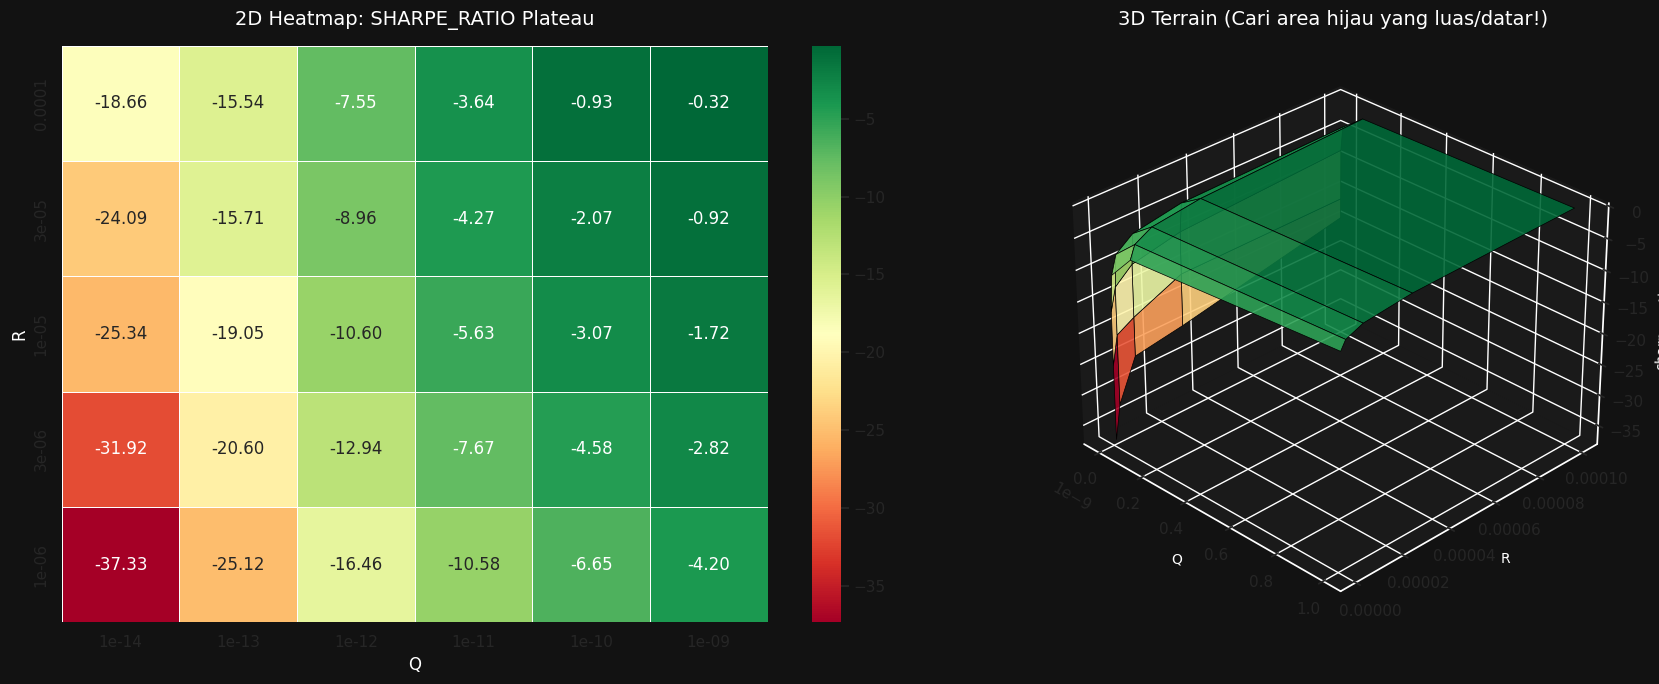

In [8]:
# ==============================================================================
# THE PLATEAU RADAR (MENCARI DATARAN TINGGI YANG AMAN DARI NOISE)
# ==============================================================================

def plot_the_plateau(df, x_param='Q', y_param='R', z_metric='sharpe_ratio'):
    """
    Mengubah Leaderboard datar menjadi Peta Topografi 3D dan Heatmap 2D.
    """
    # 1. Ekstraksi parameter dari dictionary 'params' ke dalam kolom tersendiri
    # Karena parameter tersimpan dalam dict di kolom 'params', kita harus membongkarnya
    extracted_params = df['params'].apply(pd.Series)
    plot_df = pd.concat([df[[z_metric]], extracted_params], axis=1)
    
    # Konversi ke float untuk berjaga-jaga
    plot_df[x_param] = plot_df[x_param].astype(float)
    plot_df[y_param] = plot_df[y_param].astype(float)
    plot_df[z_metric] = plot_df[z_metric].astype(float)

    # 2. Pivot Table untuk membuat Grid Heatmap
    # Mengambil rata-rata Sharpe Ratio jika ada duplikasi parameter lain (misal entry_z)
    grid = plot_df.pivot_table(index=y_param, columns=x_param, values=z_metric, aggfunc='mean')
    
    # 3. Setup Canvas (2 Grafik: Heatmap 2D & Surface 3D)
    fig = plt.figure(figsize=(18, 7))
    
    # --- GRAFIK 1: 2D HEATMAP ---
    ax1 = fig.add_subplot(1, 2, 1)
    sns.heatmap(grid, annot=True, cmap="RdYlGn", fmt=".2f", linewidths=.5, ax=ax1)
    ax1.set_title(f"2D Heatmap: {z_metric.upper()} Plateau", fontsize=14, color='white', pad=15)
    ax1.set_xlabel(x_param, fontsize=12, color='white')
    ax1.set_ylabel(y_param, fontsize=12, color='white')
    # Membalik sumbu Y agar nilai terkecil ada di bawah
    ax1.invert_yaxis() 
    
    # --- GRAFIK 2: 3D SURFACE PLOT ---
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    X, Y = np.meshgrid(grid.columns, grid.index)
    Z = grid.values
    
    surf = ax2.plot_surface(X, Y, Z, cmap="RdYlGn", edgecolor='black', linewidth=0.5, alpha=0.9)
    ax2.set_title("3D Terrain (Cari area hijau yang luas/datar!)", fontsize=14, color='white', pad=15)
    ax2.set_xlabel(x_param, fontsize=10, color='white')
    ax2.set_ylabel(y_param, fontsize=10, color='white')
    ax2.set_zlabel(z_metric, fontsize=10, color='white')
    
    # Atur sudut pandang (Elevation, Azimuth)
    ax2.view_init(elev=30, azim=-45)
    
    # Format background 3D agar gelap
    ax2.xaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
    ax2.yaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
    ax2.zaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
    
    plt.tight_layout()
    plt.show()


# PANGGIL RADARNYA! (Asumsi kita ingin melihat hubungan R dan Q)
if 'leaderboard' in locals():
    print("Memindai Topografi Parameter...")
    plot_the_plateau(leaderboard, x_param='Q', y_param='R', z_metric='sharpe_ratio')